In [1]:
library(data.table)
library(igraph)
library(dplyr)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
ppi <- fread("../results/network/STRING_PPI_network_TCGA_LUAD.tsv")

head(ppi)

#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACVRL1,SMAD6,9606.ENSP00000373574,9606.ENSP00000288840,0,0,0,0.000,0.121,0.190,0,0.520,0.628
ACVRL1,SOX17,9606.ENSP00000373574,9606.ENSP00000297316,0,0,0,0.000,0.168,0.054,0,0.387,0.476
ACVRL1,CAV1,9606.ENSP00000373574,9606.ENSP00000339191,0,0,0,0.000,0.056,0.046,0,0.507,0.517
ACVRL1,CLEC14A,9606.ENSP00000373574,9606.ENSP00000353013,0,0,0,0.000,0.344,0.098,0,0.289,0.542
ACVRL1,TEK,9606.ENSP00000373574,9606.ENSP00000369375,0,0,0,0.571,0.195,0.074,0,0.268,0.407
ACVRL1,PECAM1,9606.ENSP00000373574,9606.ENSP00000457421,0,0,0,0.000,0.178,0.081,0,0.328,0.448


In [3]:
network <- graph_from_data_frame(
  ppi[, .(node1, node2)],
  directed = FALSE
)

network

ERROR: Error in eval(jsub, SDenv, parent.frame()): object 'node1' not found


In [4]:
colnames(ppi)

[1] "#node1"                               
 [2] "node2"                                
 [3] "node1_string_id"                      
 [4] "node2_string_id"                      
 [5] "neighborhood_on_chromosome"           
 [6] "gene_fusion"                          
 [7] "phylogenetic_cooccurrence"            
 [8] "homology"                             
 [9] "coexpression"                         
[10] "experimentally_determined_interaction"
[11] "database_annotated"                   
[12] "automated_textmining"                 
[13] "combined_score"

In [5]:
head(ppi)

#node1,node2,node1_string_id,node2_string_id,neighborhood_on_chromosome,gene_fusion,phylogenetic_cooccurrence,homology,coexpression,experimentally_determined_interaction,database_annotated,automated_textmining,combined_score
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACVRL1,SMAD6,9606.ENSP00000373574,9606.ENSP00000288840,0,0,0,0.000,0.121,0.190,0,0.520,0.628
ACVRL1,SOX17,9606.ENSP00000373574,9606.ENSP00000297316,0,0,0,0.000,0.168,0.054,0,0.387,0.476
ACVRL1,CAV1,9606.ENSP00000373574,9606.ENSP00000339191,0,0,0,0.000,0.056,0.046,0,0.507,0.517
ACVRL1,CLEC14A,9606.ENSP00000373574,9606.ENSP00000353013,0,0,0,0.000,0.344,0.098,0,0.289,0.542
ACVRL1,TEK,9606.ENSP00000373574,9606.ENSP00000369375,0,0,0,0.571,0.195,0.074,0,0.268,0.407
ACVRL1,PECAM1,9606.ENSP00000373574,9606.ENSP00000457421,0,0,0,0.000,0.178,0.081,0,0.328,0.448


In [6]:
network <- graph_from_data_frame(
  ppi[, .(`#node1`, node2)],
  directed = FALSE
)

network

IGRAPH dc15c0b UN-- 215 5672 -- 
+ attr: name (v/c)
+ edges from dc15c0b (vertex names):
 [1] ACVRL1  --SMAD6   ACVRL1  --SOX17   ACVRL1  --CAV1    ACVRL1  --CLEC14A
 [5] ACVRL1  --TEK     ACVRL1  --PECAM1  ACVRL1  --TMEM100 ACVRL1  --CDH5   
 [9] ADM2    --RAMP3   ADM2    --RAMP2   ADM2    --CALCRL  ADRB2   --SLC6A4 
[13] ADRB2   --SLC2A1  ADRB2   --GRK5    AGER    --FABP4   AGER    --CAV1   
[17] AGER    --HMGB3   AGER    --EDNRB   ALDH18A1--CAT     ALDH18A1--PPAT   
[21] ALDH18A1--PLK1    ALDH18A1--S1PR1   ALDH18A1--AURKB   ALDH18A1--PLPP2  
[25] ALDH18A1--GPT2    ALDH18A1--TOP2A   ALDH18A1--PNPLA6  ALDH18A1--RECQL4 
[29] ALDH18A1--PAICS   ALDH18A1--PSAT1   ALDH18A1--PYCR1   ANGPT4  --EDNRB  
+ ... omitted several edges

In [7]:
degree_score <- degree(network)

betweenness_score <- betweenness(network)

closeness_score <- closeness(network)

In [8]:
hub_genes <- data.frame(
  Gene = names(degree_score),
  Degree = degree_score,
  Betweenness = betweenness_score,
  Closeness = closeness_score
)

hub_genes <- hub_genes %>%
  arrange(desc(Degree))

head(hub_genes,20)

,Gene,Degree,Betweenness,Closeness
,<chr>,<dbl>,<dbl>,<dbl>
TOP2A,TOP2A,162,830.85097,0.002136752
KIF11,KIF11,156,149.49945,0.002036660
CCNA2,CCNA2,152,1209.40204,0.002222222
CDC45,CDC45,152,358.19867,0.002044990
CDCA8,CDCA8,152,430.36111,0.002044990
CCNB1,CCNB1,150,162.91884,0.002024291
CHEK1,CHEK1,150,93.50984,0.002028398
EXO1,EXO1,150,94.00201,0.002028398
AURKB,AURKB,148,312.63429,0.002061856


In [9]:
write.csv(
  hub_genes,
  "../results/network/Hub_genes_TCGA_LUAD.csv",
  row.names = FALSE
)

In [10]:
head(hub_genes, 20)

,Gene,Degree,Betweenness,Closeness
,<chr>,<dbl>,<dbl>,<dbl>
TOP2A,TOP2A,162,830.85097,0.002136752
KIF11,KIF11,156,149.49945,0.002036660
CCNA2,CCNA2,152,1209.40204,0.002222222
CDC45,CDC45,152,358.19867,0.002044990
CDCA8,CDCA8,152,430.36111,0.002044990
CCNB1,CCNB1,150,162.91884,0.002024291
CHEK1,CHEK1,150,93.50984,0.002028398
EXO1,EXO1,150,94.00201,0.002028398
AURKB,AURKB,148,312.63429,0.002061856


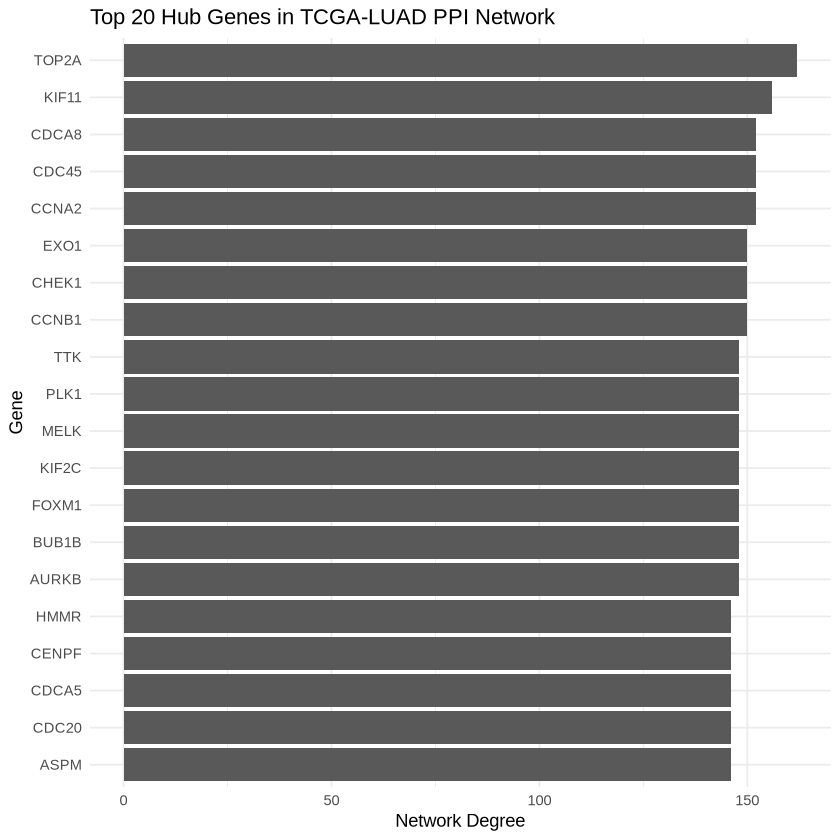

In [11]:
library(ggplot2)

top20_hubs <- hub_genes %>%
  head(20)

ggplot(top20_hubs,
       aes(x=reorder(Gene, Degree),
           y=Degree)) +
  geom_bar(stat="identity") +
  coord_flip() +
  theme_minimal() +
  labs(
    title="Top 20 Hub Genes in TCGA-LUAD PPI Network",
    x="Gene",
    y="Network Degree"
  )

In [12]:
ggsave(
"../figures/network/Top20_Hub_Genes_TCGA_LUAD.png",
width=8,
height=6,
dpi=300
)